In [113]:
import sys
sys.path.append("/project/src")

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from sksurv.metrics import integrated_brier_score, cumulative_dynamic_auc, brier_score
from sklearn.metrics import mean_squared_error, roc_curve
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from preprocessing import (
    split_features_target,
    low_missingness_complete_case_analysis,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)
from helpers import (
  save_pic,
  show_pic
)

import joblib

In [115]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
    test_df_csv = "/content/drive/MyDrive/bachelor/nacc_test.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"
    test_df_csv = "./data/nacc_test.csv"

In [116]:
train_df = pd.read_csv(train_df_csv, delimiter=',')
test_df = pd.read_csv(test_df_csv, delimiter=',')

/tmp/ipykernel_25/2510053026.py:2: DtypeWarning: Columns (4,8,27,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,190,193,195,201,203,205,207,209,211,217,219,223,227,233,235,237,245,370,372,394,405,545,576,601,672,689,706,760,763,805,813,814,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_df_csv, delimiter=',')


In [117]:
test_df.head()

,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,2.0,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.207
1,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14.144
2,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.221
3,2.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2.086
4,1.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,14.541


In [118]:
train_X, train_y = split_features_target(train_df)

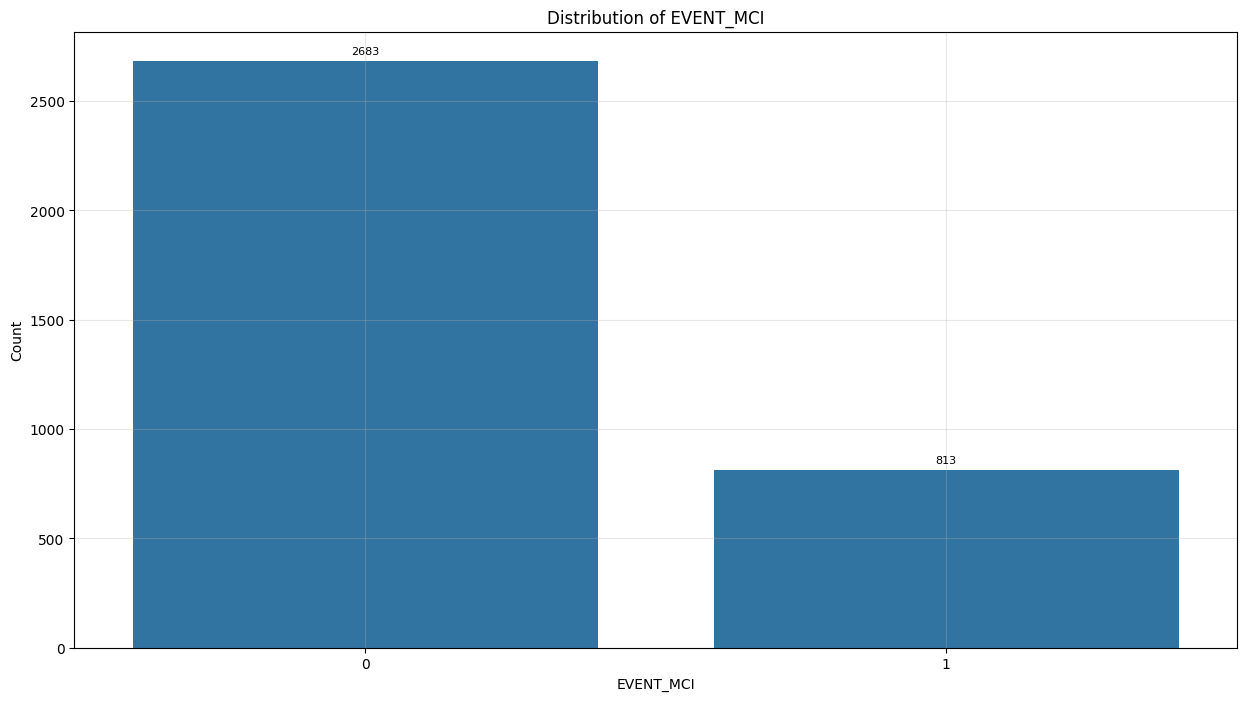

In [119]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=test_df['EVENT_MCI'].value_counts().index, y=test_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [120]:
test_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.767449
1    0.232551
Name: proportion, dtype: float64

# Cross-Validation results

In [121]:
rsf_pipeline = joblib.load("joblib-storage/rsf_best_pipeline.joblib")
preprocessor = rsf_pipeline.named_steps['preprocessor']
rsf = rsf_pipeline.named_steps['model']

In [122]:
rsf_best_params = joblib.load("joblib-storage/rsf_best_params.joblib")
print(f"Best RSF parameters: {rsf_best_params}")

Best RSF parameters: {'min_node_size': 75, 'mtry': 'sqrt', 'num_trees': np.int64(500), 'replace': True, 'sample_fraction': np.float64(0.7807153798184817)}


In [123]:
cv_cindex = joblib.load("joblib-storage/rsf_best_cv_cindex.joblib")
cv_cindex_std = joblib.load("joblib-storage/rsf_best_cv_cindex_std.joblib")
print(f"Best CV C-index: {cv_cindex:.4f} ± {cv_cindex_std:.4f}")

Best CV C-index: 0.7669 ± 0.0244


# Evaluaition on test dataset

In [124]:
fitted_low_missingness_cols = preprocessor.get_low_missingness_cols()
test_preprepared = low_missingness_complete_case_analysis(test_df, low_missingness_columns=fitted_low_missingness_cols)
test_X_raw, test_y = split_features_target(test_preprepared)
test_X = preprocessor.transform(test_X_raw)

Complete-case analysis on low-missing columns
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [125]:
test_events = test_y[SURVIVAL_EVENT_COL].astype(bool)
test_times = test_y[SURVIVAL_TIME_COL]

min_test_time = test_times.min()
max_test_time = test_times.max()

## Test c-index

In [126]:
cindex_test = rsf.score(test_X, test_y)
print(f"Test C-index: {cindex_test:.4f}")

Test C-index: 0.7632


## Test IBS

In [127]:
def calculate_ibs(rsf, test_X, test_y, event_min_time, event_max_time):
  times_ibs = np.linspace(event_min_time, event_max_time, 100)
  # RSF returns (surv_matrix, unique_death_times), interpolate to get survival probs at specific times
  surv_matrix_raw, death_times = rsf.predict_survival_function(test_X)

  # Interpolate each patient's survival curve to times_ibs
  surv_matrix = np.array([
      np.interp(times_ibs, death_times, surv_matrix_raw[i])
      for i in range(surv_matrix_raw.shape[0])
  ])

  ibs = integrated_brier_score(train_y, test_y, surv_matrix, times_ibs)
  print(f"Integrated Brier Score: {ibs:.4f}")
  return ibs, surv_matrix_raw, death_times

In [128]:
event_min_time = test_times[test_events].min()
event_max_time = test_times[test_events].max()
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

Event times range from 0.82 to 18.17 years


In [129]:
follow_up_ibs, surv_matrix_raw, death_times = calculate_ibs(rsf, test_X, test_y, event_min_time, event_max_time)

Integrated Brier Score: 0.1496


In [130]:
event_min_time = test_times[test_events].min()
event_max_time = 5
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

ibs_5_years, _, _ = calculate_ibs(rsf, test_X, test_y, event_min_time, event_max_time)

Event times range from 0.82 to 5.00 years
Integrated Brier Score: 0.0813


## Test KM and Survival curve

In [131]:
kmf = KaplanMeierFitter()
kmf.fit(test_times, event_observed=test_events)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1638 total observations, 1265 right-censored observations>

In [132]:
# Mean predicted survival curve across all patients
predicted_mean_surv = surv_matrix_raw.mean(axis=0)
predicted_surv = pd.Series(predicted_mean_surv, index=death_times)
predicted_surv.head(5)

0.145    0.999846
0.468    0.999717
0.690    0.999428
0.726    0.999261
0.786    0.999098
dtype: float64

In [133]:
times_to_plot = np.linspace(min_test_time, max_test_time, 100)

In [134]:
brier_times = np.arange(int(min_test_time)+1, int(max_test_time)+1)

# Interpolate survival curves to integer year time points for Brier score
brier_surv_matrix = np.array([
    np.interp(brier_times, death_times, surv_matrix_raw[i])
    for i in range(surv_matrix_raw.shape[0])
])

_, brier_scores = brier_score(train_y, test_y, brier_surv_matrix, brier_times)
brier_scores

array([0.01196933, 0.06322058, 0.08517752, 0.10850383, 0.12384065,
       0.13160477, 0.13597524, 0.14142063, 0.14713278, 0.15896563,
       0.17033661, 0.18035176, 0.18857464, 0.1982655 , 0.19518588,
       0.18312539, 0.1928158 , 0.20950626, 0.18537302])

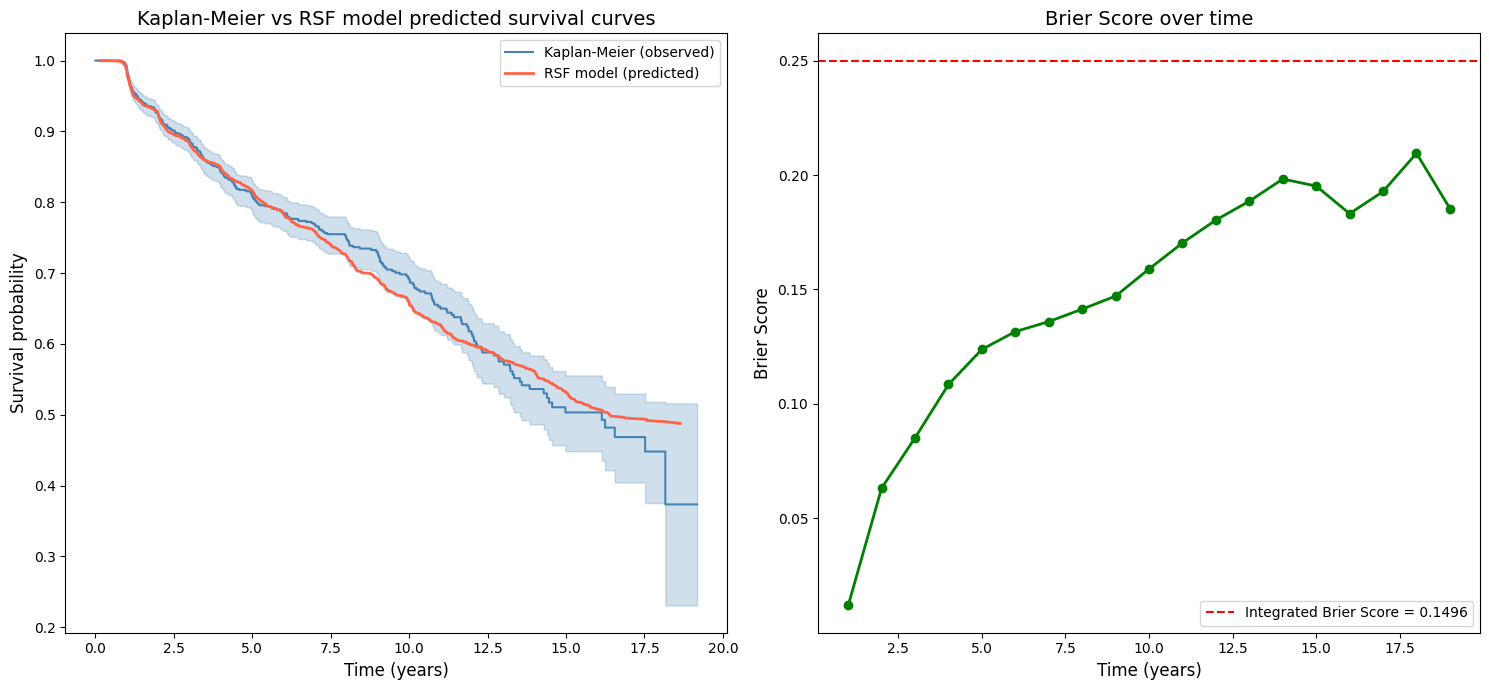

In [135]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
kmf.plot_survival_function(ax=ax[0], label="Kaplan-Meier (observed)", color="steelblue")
ax[0].plot(predicted_surv.index, predicted_surv.values, color="tomato", linewidth=2, label="RSF model (predicted)")
ax[0].set_xlabel("Time (years)", fontsize=12)
ax[0].set_ylabel("Survival probability", fontsize=12)
ax[0].set_title("Kaplan-Meier vs RSF model predicted survival curves", fontsize=14)
ax[0].legend()  

ax[1].plot(brier_times, brier_scores, color="green", marker="o", linewidth=2)
ax[1].axhline(0.25, color="red", linestyle="--", label=f"Integrated Brier Score = {follow_up_ibs:.4f}")
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[1].set_ylabel("Brier Score", fontsize=12)
ax[1].set_title("Brier Score over time", fontsize=14)
ax[1].legend()
plt.tight_layout()
save_pic(plt, "rsf_evaluation_KM_IBS.png")
plt.show()

In [136]:
times = np.linspace(min_test_time, max_test_time, 100)
pred_surv = np.array([
    np.interp(times, death_times, surv_matrix_raw[i])
    for i in range(surv_matrix_raw.shape[0])
])
predicted_mean = np.mean(pred_surv, axis=0)
kmf_surv_scores = kmf.survival_function_at_times(times).values

abs_errors = np.abs(kmf_surv_scores - predicted_mean)

rmse      = np.sqrt(mean_squared_error(kmf_surv_scores, predicted_mean))
median_ae = np.median(abs_errors)
mean_ae   = np.mean(abs_errors)

print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.0345
Median Abs Error: 0.0163
Mean Abs Error:   0.0222


## Risk groups

In [137]:
LOW_RISK_GROUP_INDICATOR = 0
MEDIUM_RISK_GROUP_INDICATOR = 1
HIGH_RISK_GROUP_INDICATOR = 2

def assign_patient_to_risk_group(score, low_cutoff, high_cutoff):
    if score <= low_cutoff:
        return LOW_RISK_GROUP_INDICATOR
    elif score <= high_cutoff:
        return MEDIUM_RISK_GROUP_INDICATOR
    else:
        return HIGH_RISK_GROUP_INDICATOR

In [138]:
times_curve = np.linspace(min_test_time, max_test_time, 100)
cdf_curve = np.array([
    np.interp(times_curve, death_times, 1 - surv_matrix_raw[i])
    for i in range(surv_matrix_raw.shape[0])
])
density_score_per_patient = cdf_curve.mean(axis=1)
surv_curve = 1 - cdf_curve

low_medium_cutoff  = np.percentile(density_score_per_patient, 33.333)
medium_high_cutoff = np.percentile(density_score_per_patient, 66.667)

In [139]:
risk_df = pd.DataFrame({
    "scores":     density_score_per_patient,
    "event":      test_y[SURVIVAL_EVENT_COL].astype(bool),
    "duration":   test_y[SURVIVAL_TIME_COL],
})
risk_df["risk_group"] = risk_df["scores"].apply(
    lambda s: assign_patient_to_risk_group(s, low_medium_cutoff, medium_high_cutoff)
)

print(f"Cutoffs: low/medium={low_medium_cutoff:.3f}, medium/high={medium_high_cutoff:.3f}")
print(f"Low risk group:    {(risk_df['risk_group'] == LOW_RISK_GROUP_INDICATOR).sum()} patients")
print(f"Medium risk group: {(risk_df['risk_group'] == MEDIUM_RISK_GROUP_INDICATOR).sum()} patients")
print(f"High risk group:   {(risk_df['risk_group'] == HIGH_RISK_GROUP_INDICATOR).sum()} patients")

Cutoffs: low/medium=0.246, medium/high=0.368
Low risk group:    546 patients
Medium risk group: 546 patients
High risk group:   546 patients


In [140]:
risk_groups_props = {
    LOW_RISK_GROUP_INDICATOR:    {"color": 'green',  "name": "Low risk"},
    MEDIUM_RISK_GROUP_INDICATOR: {"color": 'orange', "name": "Medium risk"},
    HIGH_RISK_GROUP_INDICATOR:   {"color": 'red',    "name": "High risk"}
}

low_scores    = risk_df.loc[risk_df["risk_group"] == LOW_RISK_GROUP_INDICATOR, "scores"].values
medium_scores = risk_df.loc[risk_df["risk_group"] == MEDIUM_RISK_GROUP_INDICATOR, "scores"].values
high_scores   = risk_df.loc[risk_df["risk_group"] == HIGH_RISK_GROUP_INDICATOR, "scores"].values

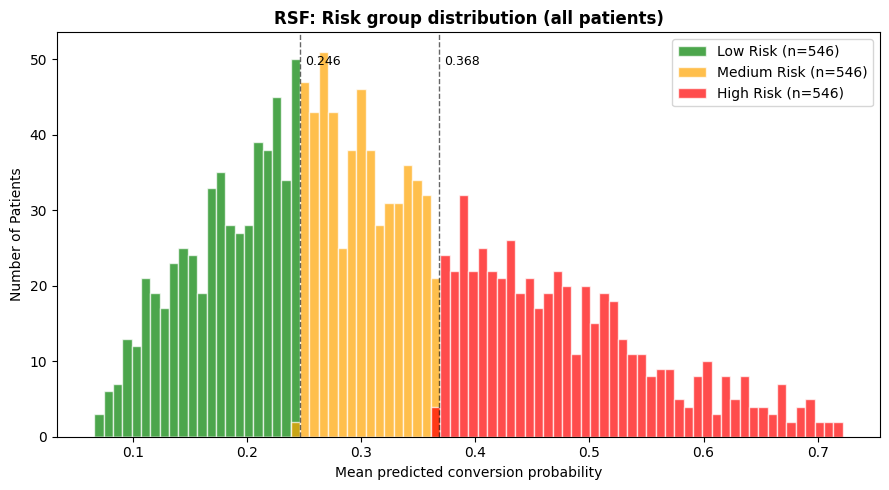

In [141]:
NUMBER_OF_BINS = 80
bin_edges = np.linspace(risk_df["scores"].min(), risk_df["scores"].max(), NUMBER_OF_BINS + 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(low_scores,    bins=bin_edges, color="green",  label=f"Low Risk (n={len(low_scores)})",    edgecolor="white", alpha=0.7)
ax.hist(medium_scores, bins=bin_edges, color="orange", label=f"Medium Risk (n={len(medium_scores)})", edgecolor="white", alpha=0.7)
ax.hist(high_scores,   bins=bin_edges, color="red",    label=f"High Risk (n={len(high_scores)})",   edgecolor="white", alpha=0.7)

ax.axvline(low_medium_cutoff,  color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(medium_high_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
ymax = ax.get_ylim()[1]
ax.text(low_medium_cutoff + 0.005,  ymax * 0.92, f'{low_medium_cutoff:.3f}',  fontsize=9)
ax.text(medium_high_cutoff + 0.005, ymax * 0.92, f'{medium_high_cutoff:.3f}', fontsize=9)

ax.set_xlabel("Mean predicted conversion probability", fontsize=10)
ax.set_ylabel("Number of Patients", fontsize=10)
ax.set_title("RSF: Risk group distribution (all patients)", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
save_pic(plt, "rsf_evaluation_Risk_Groups.png")
plt.show()

In [142]:
print(f"Predicted conversion probability at end of follow-up ({times_curve[-1]:.2f} years):")
group_risk_probs = {}
for grp, name in [(LOW_RISK_GROUP_INDICATOR, "Low"),
                  (MEDIUM_RISK_GROUP_INDICATOR, "Medium"),
                  (HIGH_RISK_GROUP_INDICATOR, "High")]:
    mask = (risk_df["risk_group"] == grp).values
    prob = cdf_curve[mask].mean(axis=0)[-1] * 100
    group_risk_probs[grp] = prob
    print(f"  {name:<7} risk: {prob:.1f}%  (n={mask.sum()})")

Predicted conversion probability at end of follow-up (19.18 years):
  Low     risk: 34.5%  (n=546)
  Medium  risk: 50.8%  (n=546)
  High    risk: 68.4%  (n=546)


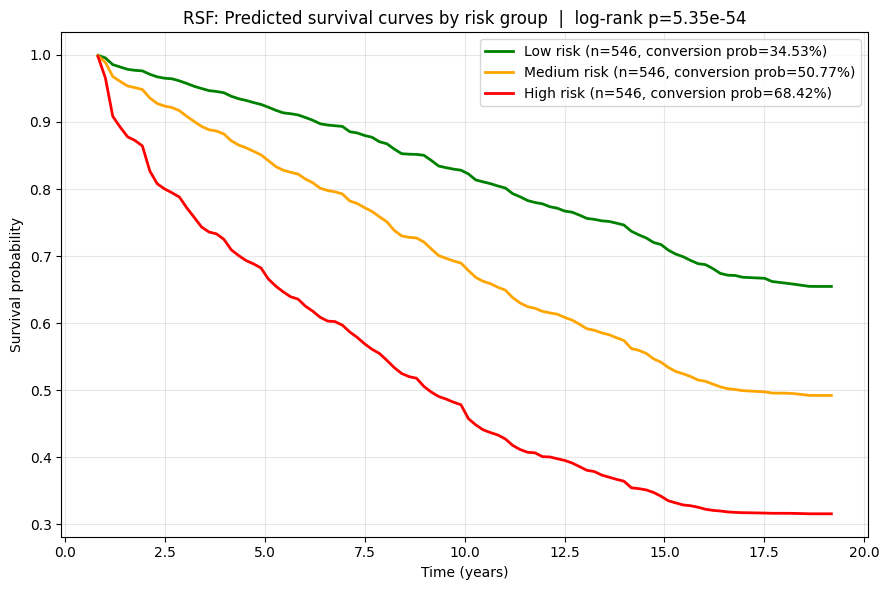

In [143]:
overall = multivariate_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)

fig, ax = plt.subplots(figsize=(9, 6))

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = (risk_df['risk_group'] == group).values
    mean_surv = surv_curve[mask].mean(axis=0)
    ax.plot(times_curve, mean_surv,
            color=risk_groups_props[group]["color"], linewidth=2,
            label=f'{risk_groups_props[group]["name"]} (n={mask.sum()}, conversion prob={group_risk_probs[group]:.2f}%)')

ax.set_xlabel("Time (years)")
ax.set_ylabel("Survival probability")
ax.set_title(f"RSF: Predicted survival curves by risk group  |  log-rank p={overall.p_value:.2e}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
save_pic(plt, "rsf_evaluation_Risk_Groups_KM.png")
plt.show()

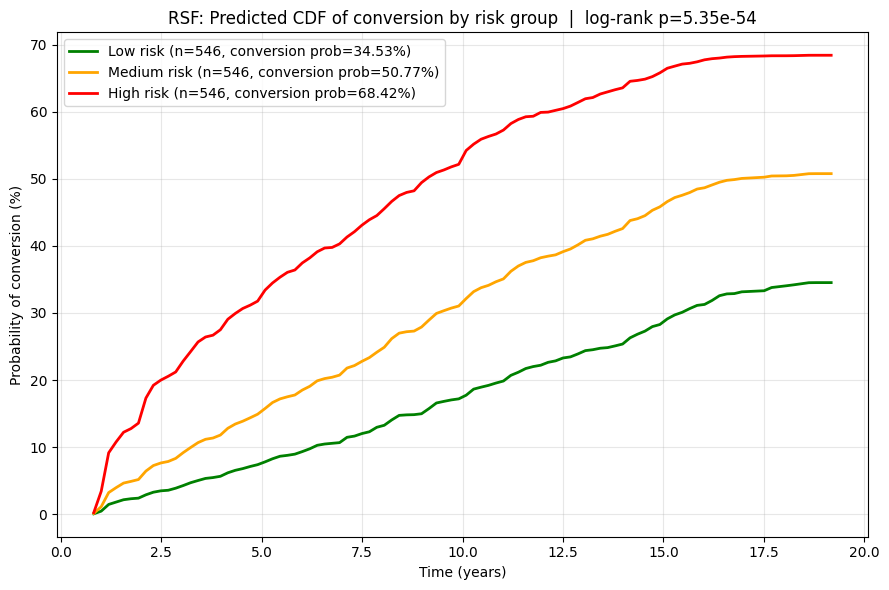

In [144]:
overall = multivariate_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)

fig, ax = plt.subplots(figsize=(9, 6))

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = (risk_df['risk_group'] == group).values
    mean_conv = cdf_curve[mask].mean(axis=0) * 100   # CDF in %
    ax.plot(times_curve, mean_conv,
            color=risk_groups_props[group]["color"], linewidth=2,
            label=f'{risk_groups_props[group]["name"]} (n={mask.sum()}, conversion prob={group_risk_probs[group]:.2f}%)')

ax.set_xlabel("Time (years)")
ax.set_ylabel("Probability of conversion (%)")
ax.set_title(f"RSF: Predicted CDF of conversion by risk group  |  log-rank p={overall.p_value:.2e}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
save_pic(plt, "rsf_evaluation_Risk_Groups_CDF.png")
plt.show()

### Analyse significance of group separation

In [145]:
overall = multivariate_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)
overall.print_summary()
print(f"Overall log-rank p-value: {overall.p_value:.20f}")

pairwise = pairwise_logrank_test(
    risk_df['duration'],
    risk_df['risk_group'],
    risk_df['event']
)
pairwise.print_summary()

Overall log-rank p-value: 0.00000000000000000000


## Time dependent ROC-AUC

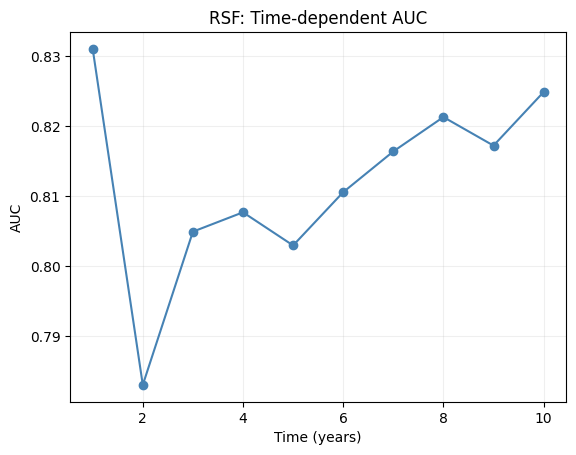

AUC at 1 year(s): 0.8311
AUC at 2 year(s): 0.7830
AUC at 3 year(s): 0.8049
AUC at 4 year(s): 0.8077
AUC at 5 year(s): 0.8029
AUC at 6 year(s): 0.8106
AUC at 7 year(s): 0.8164
AUC at 8 year(s): 0.8213
AUC at 9 year(s): 0.8172
AUC at 10 year(s): 0.8249
Mean AUC:          0.8070


In [146]:
times_roc   = np.arange(1, 11)
risk_scores = rsf.predict(test_X)
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("RSF: Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

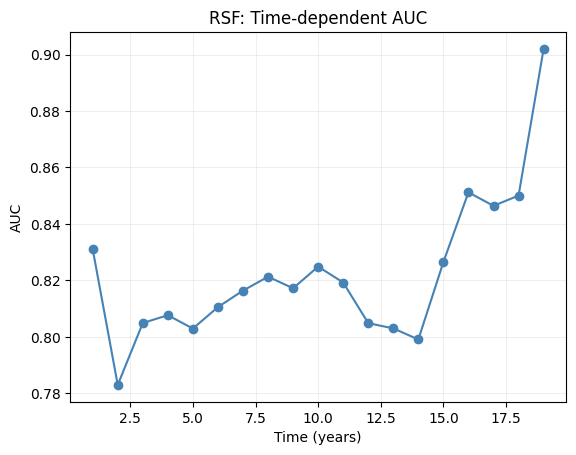

AUC at 1 year(s): 0.8311
AUC at 2 year(s): 0.7830
AUC at 3 year(s): 0.8049
AUC at 4 year(s): 0.8077
AUC at 5 year(s): 0.8029
AUC at 6 year(s): 0.8106
AUC at 7 year(s): 0.8164
AUC at 8 year(s): 0.8213
AUC at 9 year(s): 0.8172
AUC at 10 year(s): 0.8249
AUC at 11 year(s): 0.8193
AUC at 12 year(s): 0.8049
AUC at 13 year(s): 0.8030
AUC at 14 year(s): 0.7991
AUC at 15 year(s): 0.8265
AUC at 16 year(s): 0.8512
AUC at 17 year(s): 0.8464
AUC at 18 year(s): 0.8500
AUC at 19 year(s): 0.9020
Mean AUC:          0.8228


In [147]:
times_roc   = np.arange(int(min_test_time)+1, int(max_test_time) + 1)
risk_scores = rsf.predict(test_X)
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("RSF: Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")

In [148]:
for t in times_roc:
  cases = (test_times >= t) & (test_events == True)
  controls = test_times >= t
  cases_num = cases.sum()
  controls_num = controls.sum()
  print(f"At time {t:.0f} years: {cases_num} cases, {controls_num} controls, {cases_num/controls_num:.2f} cases/controls ratio")

At time 1 years: 353 cases, 1573 controls, 0.22 cases/controls ratio
At time 2 years: 260 cases, 1278 controls, 0.20 cases/controls ratio
At time 3 years: 212 cases, 1080 controls, 0.20 cases/controls ratio
At time 4 years: 160 cases, 900 controls, 0.18 cases/controls ratio
At time 5 years: 127 cases, 747 controls, 0.17 cases/controls ratio
At time 6 years: 106 cases, 611 controls, 0.17 cases/controls ratio
At time 7 years: 95 cases, 508 controls, 0.19 cases/controls ratio
At time 8 years: 83 cases, 420 controls, 0.20 cases/controls ratio
At time 9 years: 72 cases, 347 controls, 0.21 cases/controls ratio
At time 10 years: 55 cases, 297 controls, 0.19 cases/controls ratio
At time 11 years: 40 cases, 236 controls, 0.17 cases/controls ratio
At time 12 years: 28 cases, 174 controls, 0.16 cases/controls ratio
At time 13 years: 18 cases, 129 controls, 0.14 cases/controls ratio
At time 14 years: 10 cases, 98 controls, 0.10 cases/controls ratio
At time 15 years: 5 cases, 68 controls, 0.07 case

Using timepoints: [1, 3, 5]
AUC scores: [0.83105288 0.8049052  0.80293296]


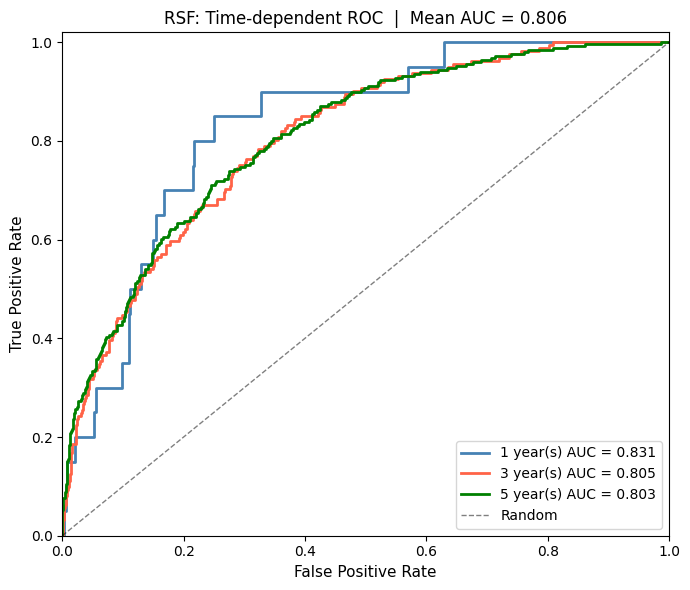

In [149]:
times_roc = [1, 3, 5]
print(f"Using timepoints: {times_roc}")

risk_scores_roc = rsf.predict(test_X)
auc_scores, mean_auc = cumulative_dynamic_auc(
    train_y, test_y, risk_scores_roc, times_roc
)
print(f"AUC scores: {auc_scores}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'tomato', 'green']

for t, auc_val, color in zip(times_roc, auc_scores, colors):
    known_mask    = (test_y[SURVIVAL_EVENT_COL].astype(bool)) | (test_y[SURVIVAL_TIME_COL] >= t)
    y_true_binary = ((test_y[SURVIVAL_EVENT_COL].astype(bool)) & (test_y[SURVIVAL_TIME_COL] <= t))[known_mask].astype(int)
    risk_known    = risk_scores_roc[known_mask]

    fpr, tpr, _   = roc_curve(y_true_binary, risk_known)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{t} year(s) AUC = {auc_val:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"RSF: Time-dependent ROC  |  Mean AUC = {mean_auc:.3f}",
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
save_pic(plt, "rsf_evaluation_ROC_AUCs.png")
plt.show()

# Summary results

## CV C-index

In [150]:
print(f"cross-validation C-index: {cv_cindex:.2f} ± {cv_cindex_std:.2f}")

cross-validation C-index: 0.77 ± 0.02


## Test C-index

In [151]:
print(f"Test C-index: {cindex_test:.2f}")

Test C-index: 0.76


## IBS score

In [152]:
print(f"IBS score for the entire follow-up period: {follow_up_ibs:.3f}")
print(f"IBS score for the first 5 years: {ibs_5_years:.3f}")

IBS score for the entire follow-up period: 0.150
IBS score for the first 5 years: 0.081


## KM curve

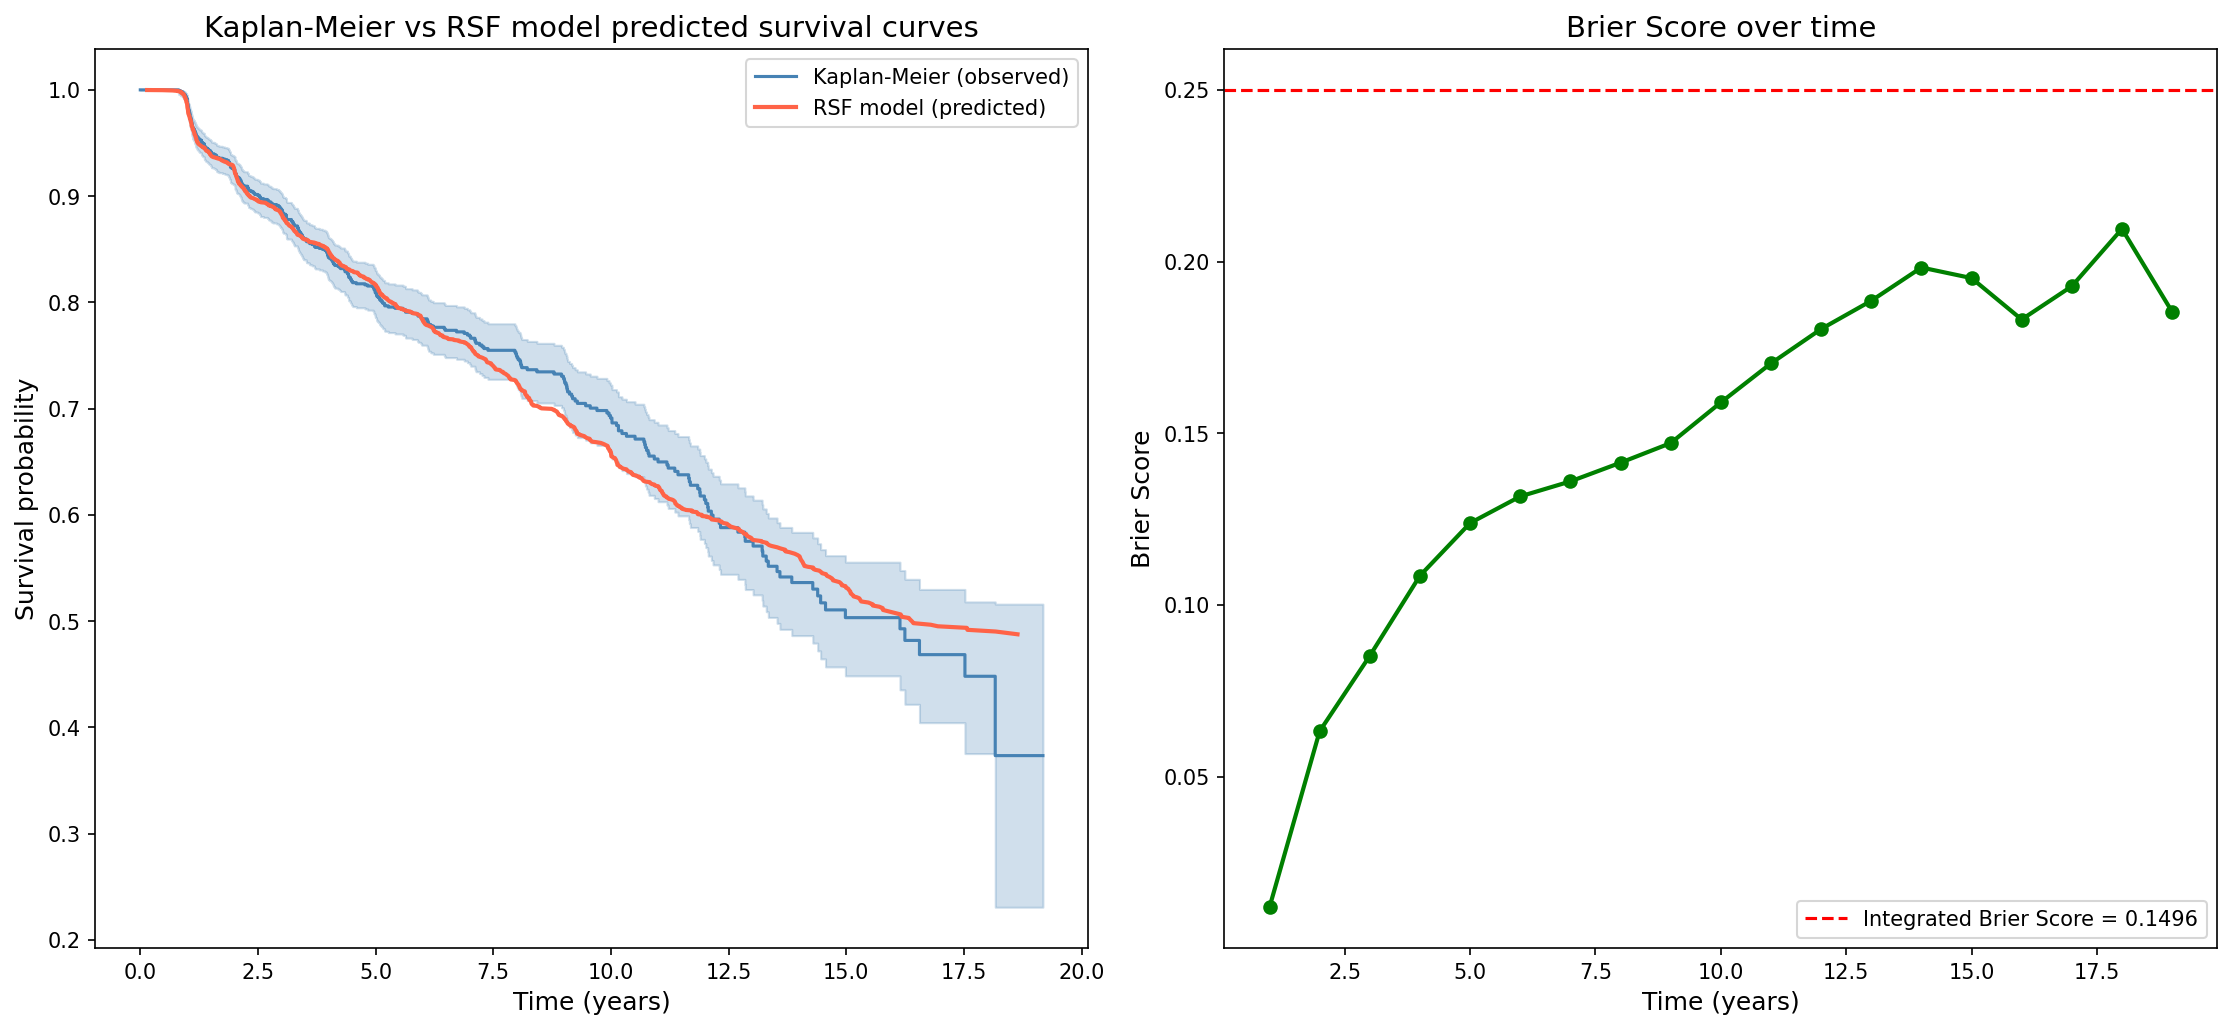

In [153]:
show_pic("rsf_evaluation_KM_IBS.png")

In [154]:
print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.0345
Median Abs Error: 0.0163
Mean Abs Error:   0.0222


## Risk groups

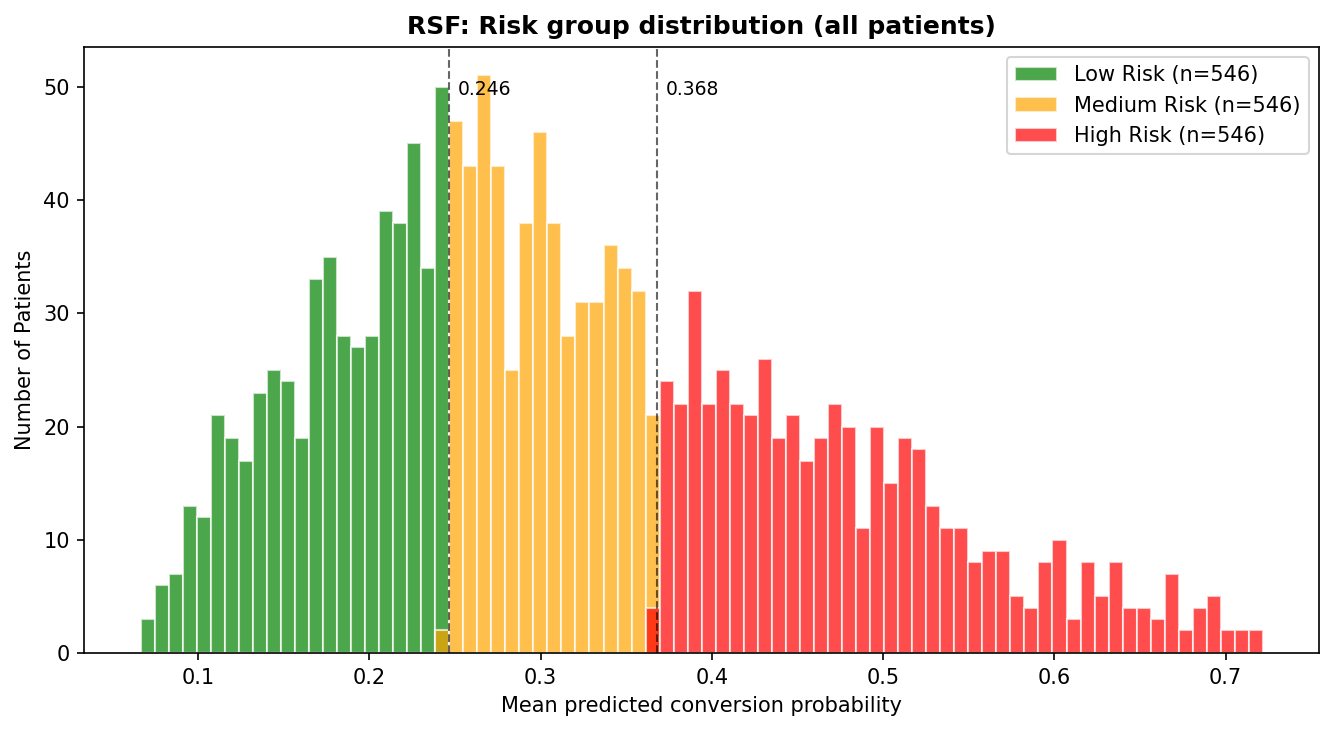

In [155]:
show_pic("rsf_evaluation_Risk_Groups.png")

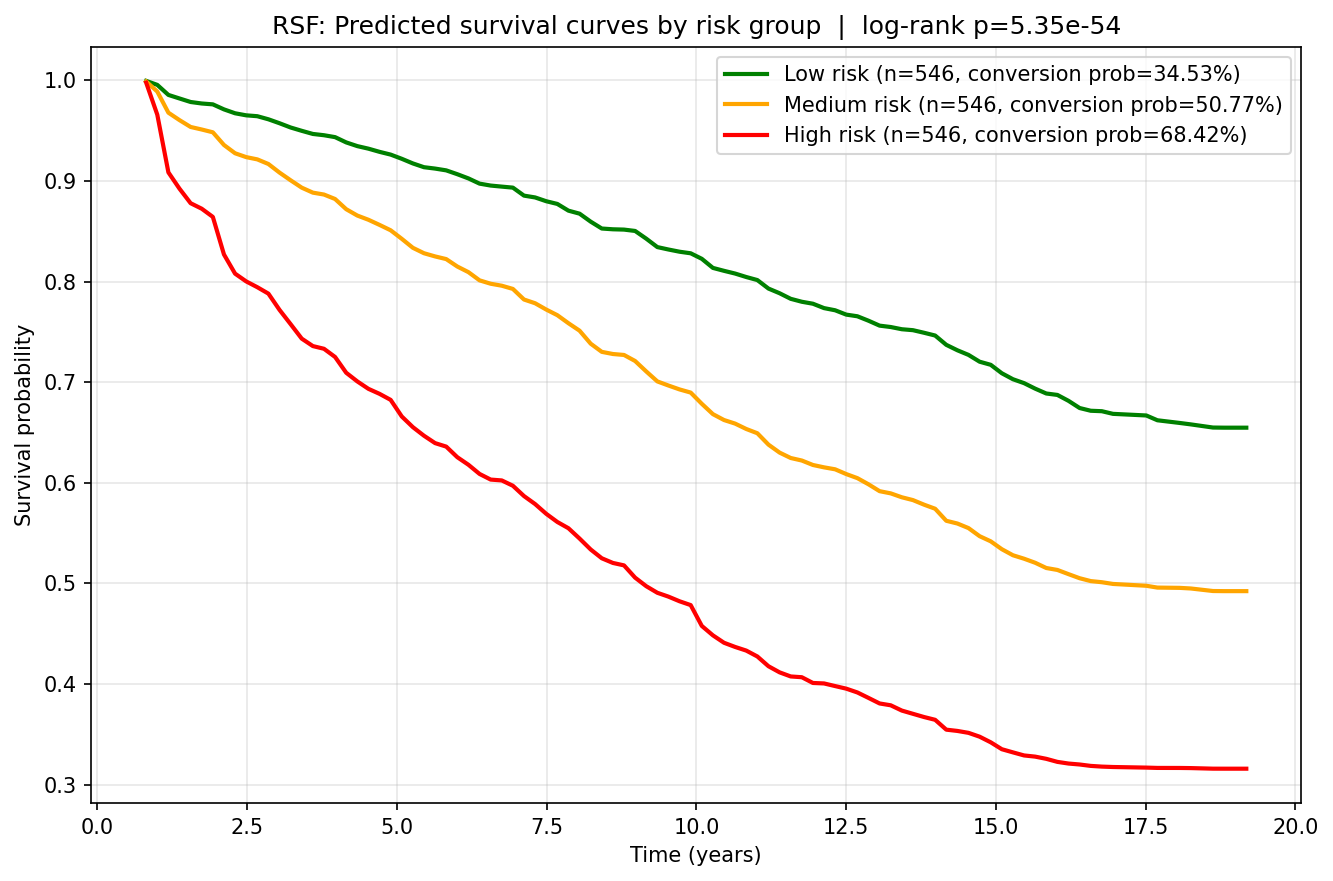

In [156]:
show_pic("rsf_evaluation_Risk_Groups_KM.png")

In [157]:
for gr in group_risk_probs:
    print(f"{risk_groups_props[gr]['name']} conversion probability: {group_risk_probs[gr]:.2f}%")

Low risk conversion probability: 34.53%
Medium risk conversion probability: 50.77%
High risk conversion probability: 68.42%


### Risk groups long-rank tests results

In [158]:
pairwise.print_summary()

In [159]:
overall.print_summary()

In [160]:

risk_df.groupby('risk_group')['scores'].mean().rename(index={0: 'low', 1: 'medium', 2: 'high'})


risk_group
low       0.180300
medium    0.302333
high      0.483276
Name: scores, dtype: float64

## Integrated ROC-AUC

In [161]:
print(f"Using timepoints (in years): {times_roc}")
print(f"AUC scores: {np.round(auc_scores, 3)}")

Using timepoints (in years): [1, 3, 5]
AUC scores: [0.831 0.805 0.803]


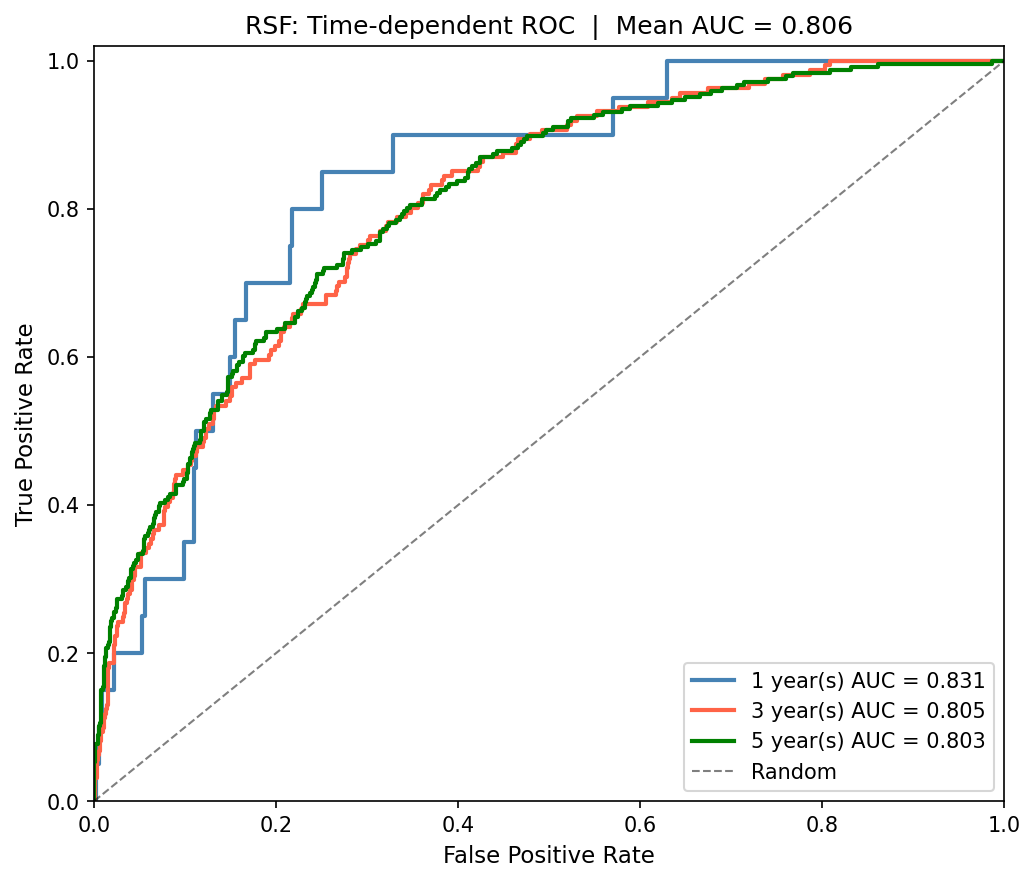

In [162]:
show_pic("rsf_evaluation_ROC_AUCs.png")